In [24]:
# ============================================================
# TopicEvalBench
# Notebook 2 : Data Preprocessing & Cross Validation
#
# Purpose:
#   1. Load dataset
#   2. Clean text
#   3. Tokenize
#   4. Encode labels
#   5. Create Stratified 5-Fold splits
#   6. Save folds for later notebooks
#
# NOTE:
# No LDA model is trained here.
# No Dictionary is built here.
# Dictionary construction belongs to Notebook 3
# to avoid data leakage.
# ============================================================

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:

# ============================================================
# Create TREC.xlsx from G2005 data
# ============================================================

import ast
import pandas as pd
from pathlib import Path

#------------------------------------------------------------
# File paths
#------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/TopicEvalBench")

DATA_DIR = ROOT / "data"

SOURCE_FILE = DATA_DIR / "OnlyDeeplyRelaGeno2005.csv"

TOPIC_FILE = DATA_DIR / "1_Dataset.txt"

PMID_FILE = DATA_DIR / "randomly_selected_pmids_each_topic.txt"

OUTPUT_FILE = DATA_DIR / "TREC.xlsx"

#------------------------------------------------------------
# Read source dataset (TAB separated)
#------------------------------------------------------------

df = pd.read_csv(
    SOURCE_FILE,
    sep="\t",
    engine="python"
)

print("Total documents:", len(df))

#------------------------------------------------------------
# Read selected topics
#------------------------------------------------------------

with open(TOPIC_FILE, "r") as f:
    topic_dictionary = ast.literal_eval(f.read())

selected_topics = topic_dictionary["G2005"]

print("Selected Topics")

print(selected_topics)

#------------------------------------------------------------
# Read selected PubMed IDs
#------------------------------------------------------------

with open(PMID_FILE, "r") as f:
    pmid_dictionary = ast.literal_eval(f.read())

#------------------------------------------------------------
# Collect selected documents
#------------------------------------------------------------

frames = []

for topic in selected_topics:

    pmids = pmid_dictionary[topic]

    subset = df[
        (df["TOPIC_NO"] == topic) &
        (df["PUBMED_IDENTIFIER"].isin(pmids))
    ]

    frames.append(subset)

trec = pd.concat(frames, ignore_index=True)

#------------------------------------------------------------
# Keep only required columns
#------------------------------------------------------------

trec = trec[
    [
        "PUBMED_IDENTIFIER",
        "ABSTRACT",
        "TOPIC_NO"
    ]
]

trec.columns = [
    "DocumentID",
    "Text",
    "Label"
]

#------------------------------------------------------------
# Remove duplicate documents
#------------------------------------------------------------

trec = trec.drop_duplicates(subset="DocumentID")

#------------------------------------------------------------
# Remove missing abstracts
#------------------------------------------------------------

trec = trec.dropna(subset=["Text"])

trec = trec.reset_index(drop=True)

#------------------------------------------------------------
# Sort
#------------------------------------------------------------

trec = trec.sort_values(
    ["Label", "DocumentID"]
)

#------------------------------------------------------------
# Save
#------------------------------------------------------------

trec.to_excel(
    OUTPUT_FILE,
    index=False
)

print("\nTREC.xlsx created successfully.\n")

print("Total Documents :", len(trec))

print("\nDocuments per Topic\n")

print(trec["Label"].value_counts().sort_index())

Total documents: 1539
Selected Topics
[108, 109, 111, 114, 116, 117, 120, 126, 142, 146]

TREC.xlsx created successfully.

Total Documents : 300

Documents per Topic

Label
108    30
109    30
111    30
114    30
116    30
117    30
120    30
126    30
142    30
146    30
Name: count, dtype: int64


In [27]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

In [28]:
from pathlib import Path
import json

PROJECT_ROOT = Path("/content/drive/MyDrive/TopicEvalBench")

CONFIG_FILE = PROJECT_ROOT / "config" / "config.json"

with open(CONFIG_FILE) as f:
    CONFIG = json.load(f)

SEED = CONFIG["random_seed"]

DATA_DIR = PROJECT_ROOT / "data"

FOLD_DIR = PROJECT_ROOT / "folds"

print("Configuration Loaded")

Configuration Loaded


In [29]:
DATASET_FILE = DATA_DIR / "TREC.xlsx"

df = pd.read_excel(DATASET_FILE)

print(df.shape)

df.head()

(300, 3)


,DocumentID,Text,Label
0,8042410,Development of primary cultured chicken myogen...,108
1,8132718,Constitutive centripetal transport of the acti...,108
2,8673465,BACKGROUND: The green fluorescent protein (GFP...,108
3,8707050,We report fluorescent resonance energy transfe...,108
4,9175625,The trafficking of the androgen receptor (AR) ...,108


In [30]:
print(df.columns)

print(df.info())

print(df.isnull().sum())

Index(['DocumentID', 'Text', 'Label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   DocumentID  300 non-null    int64 
 1   Text        300 non-null    object
 2   Label       300 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 7.2+ KB
None
DocumentID    0
Text          0
Label         0
dtype: int64


In [31]:
encoder = LabelEncoder()

df["LabelID"] = encoder.fit_transform(df["Label"])

mapping = pd.DataFrame({

    "Label":encoder.classes_,

    "ID":range(len(encoder.classes_))

})

mapping.to_csv(

DATA_DIR/"LabelMapping.csv",

index=False

)

mapping

,Label,ID
0,108,0
1,109,1
2,111,2
3,114,3
4,116,4
5,117,5
6,120,6
7,126,7
8,142,8
9,146,9


In [32]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [33]:
def preprocess(text):
    """
    Basic preprocessing for LDA.

    Parameters
    ----------
    text : str

    Returns
    -------
    list
        List of processed tokens.
    """

    if pd.isna(text):
        return []

    text = str(text).lower()

    words = word_tokenize(text)

    words = [w for w in words if w.isalpha()]

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return words

In [34]:
df["Tokens"] = df["Text"].apply(preprocess)

df[["Text","Tokens"]].head()

,Text,Tokens
0,Development of primary cultured chicken myogen...,"[development, primary, cultured, chicken, myog..."
1,Constitutive centripetal transport of the acti...,"[constitutive, centripetal, transport, cytoske..."
2,BACKGROUND: The green fluorescent protein (GFP...,"[background, green, fluorescent, protein, gfp,..."
3,We report fluorescent resonance energy transfe...,"[report, fluorescent, resonance, energy, trans..."
4,The trafficking of the androgen receptor (AR) ...,"[trafficking, androgen, receptor, ar, transfec..."


In [35]:
doc_lengths = df["Tokens"].apply(len)

print("="*60)

print("Documents :",len(df))

print("Average Length :",doc_lengths.mean())

print("Median Length :",doc_lengths.median())

print("Maximum Length :",doc_lengths.max())

print("Minimum Length :",doc_lengths.min())

print("="*60)

vocabulary = set()

for tokens in df["Tokens"]:
    vocabulary.update(tokens)

print("Vocabulary Size :",len(vocabulary))

Documents : 300
Average Length : 108.18333333333334
Median Length : 106.0
Maximum Length : 239
Minimum Length : 25
Vocabulary Size : 4601


Label
108    30
109    30
111    30
114    30
116    30
117    30
120    30
126    30
142    30
146    30
Name: count, dtype: int64


<Axes: xlabel='Label'>

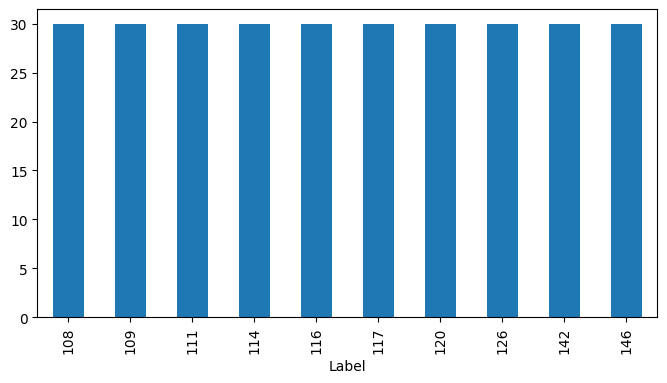

In [36]:
distribution = df["Label"].value_counts()

print(distribution)

distribution.plot.bar(figsize=(8,4))

In [37]:
skf = StratifiedKFold(

    n_splits=CONFIG["n_folds"],

    shuffle=True,

    random_state=SEED

)

for fold,(train_index,test_index) in enumerate(

        skf.split(df,df["LabelID"]),1):

    train_df = df.iloc[train_index].reset_index(drop=True)

    test_df = df.iloc[test_index].reset_index(drop=True)

    fold_path = FOLD_DIR/f"Fold_{fold}"

    fold_path.mkdir(parents=True,exist_ok=True)

    train_df.to_excel(

        fold_path/"train.xlsx",

        index=False

    )

    test_df.to_excel(

        fold_path/"test.xlsx",

        index=False

    )

    print(f"Fold {fold} Saved")

Fold 1 Saved
Fold 2 Saved
Fold 3 Saved
Fold 4 Saved
Fold 5 Saved


In [38]:
for fold in range(1,CONFIG["n_folds"]+1):

    print("="*50)

    print(f"Fold {fold}")

    train = pd.read_excel(

        FOLD_DIR/f"Fold_{fold}"/"train.xlsx"

    )

    print(train["Label"].value_counts())

    print()

Fold 1
Label
108    24
109    24
111    24
114    24
116    24
117    24
120    24
126    24
142    24
146    24
Name: count, dtype: int64

Fold 2
Label
108    24
109    24
111    24
114    24
116    24
117    24
120    24
126    24
142    24
146    24
Name: count, dtype: int64

Fold 3
Label
108    24
109    24
111    24
114    24
116    24
117    24
120    24
126    24
142    24
146    24
Name: count, dtype: int64

Fold 4
Label
108    24
109    24
111    24
114    24
116    24
117    24
120    24
126    24
142    24
146    24
Name: count, dtype: int64

Fold 5
Label
108    24
109    24
111    24
114    24
116    24
117    24
120    24
126    24
142    24
146    24
Name: count, dtype: int64



In [39]:
df.to_pickle(

DATA_DIR/"ProcessedDataset.pkl"

)

print("Processed Dataset Saved")

Processed Dataset Saved


In [40]:
print("="*70)

print("Notebook 2 Completed Successfully")

print("="*70)

print("Dataset :",DATASET_FILE.name)

print("Documents :",len(df))

print("Classes :",df["Label"].nunique())

print("Folds :",CONFIG["n_folds"])

print("Output :",FOLD_DIR)

print("="*70)

Notebook 2 Completed Successfully
Dataset : TREC.xlsx
Documents : 300
Classes : 10
Folds : 5
Output : /content/drive/MyDrive/TopicEvalBench/folds
